In [1]:
import pandas as pd
import numpy as np

In [2]:
# Optionally, save to CSV for later use
# data.to_csv('green transportation system.csv', index=False)

In [3]:
data = pd.read_csv('/content/Electric Vehicle Trip Energy Consumption Data.csv')
data.head()

,Trip Energy Consumption,Vehicle ID,Trip Distance,Time of Day,Day of the Week,Longitude,Latitude,Speed,Current,Total Voltage,Maximum Cell Temperature of Battery,Minimum Cell Temperature of Battery,Trip Time Length
0,0.672,1,6,10.333333,4,121.497948,31.281574,246.000000,2.583348,308.283333,31.000000,30.833333,13
1,0.896,1,6,16.000000,4,121.587564,31.256070,393.714286,2.985729,304.485714,29.000000,28.000000,18
2,1.344,1,7,16.090909,2,121.576968,31.262034,192.000000,2.354560,308.463636,31.272727,30.000000,21
3,1.344,1,8,19.000000,5,121.549709,31.257796,369.240000,1.540015,308.060000,30.000000,30.000000,16
4,0.896,1,6,14.166667,6,121.582280,31.215030,413.450617,9.659892,304.473457,28.000000,28.000000,129


In [4]:
from sklearn.preprocessing import StandardScaler

In [5]:

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In [6]:

# Convert the scaled data into a DataFrame for easier analysis
scaled_data = pd.DataFrame(data_scaled, columns=data.columns)
# Display the standardized data
print(scaled_data.head())

   Trip Energy Consumption  Vehicle ID  Trip Distance  Time of Day  \
0                -1.155593   -1.645363      -0.957325    -0.662711   
1                -1.076685   -1.645363      -0.957325     0.458287   
2                -0.918870   -1.645363      -0.880829     0.476271   
3                -0.918870   -1.645363      -0.804333     1.051756   
4                -1.076685   -1.645363      -0.957325     0.095611   

   Day of the Week  Longitude  Latitude     Speed   Current  Total Voltage  \
0         0.397591   0.063541  0.013021  1.950913 -0.254241       0.844504   
1         0.397591   0.100683  0.009282  3.518479 -0.184306      -0.237685   
2        -0.605503   0.096291  0.010156  1.377857 -0.294005       0.895884   
3         0.899138   0.084993  0.009535  3.258755 -0.435576       0.780862   
4         1.400685   0.098493  0.003264  3.727924  0.975689      -0.241178   

   Maximum Cell Temperature of Battery  Minimum Cell Temperature of Battery  \
0                             2

In [7]:
from sklearn.decomposition import PCA

In [8]:

# Initialize PCA
pca = PCA()

In [9]:

# Fit PCA on the scaled data
pca.fit(data_scaled)
# Explained variance ratio for each principal component
print("Explained variance ratio for each principal component:")
print(pca.explained_variance_ratio_)
# Cumulative explained variance
print("\nCumulative explained variance:")
print(np.cumsum(pca.explained_variance_ratio_))

Explained variance ratio for each principal component:
[0.17381919 0.15440577 0.14788273 0.08114928 0.07826067 0.0768543
 0.07614738 0.07487666 0.06383403 0.04638809 0.02054896 0.00534724
 0.00048571]

Cumulative explained variance:
[0.17381919 0.32822495 0.47610768 0.55725695 0.63551763 0.71237193
 0.78851931 0.86339597 0.92723    0.97361809 0.99416705 0.99951429
 1.        ]


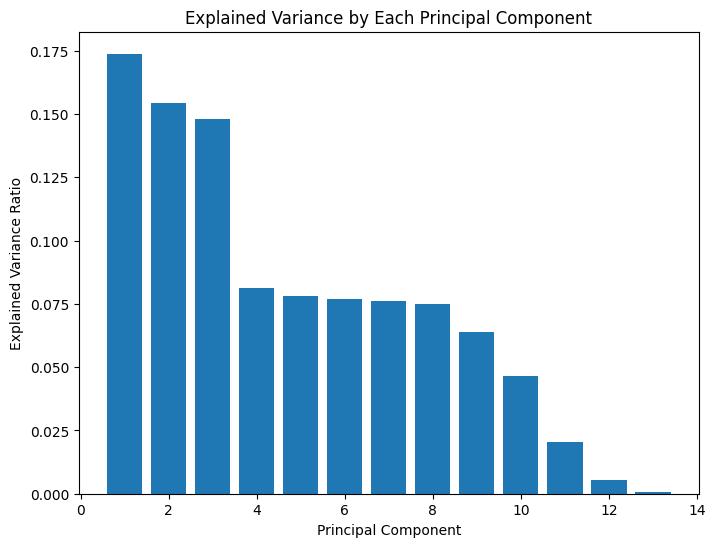

In [10]:
import matplotlib.pyplot as plt

# Plot the explained variance ratio
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.title('Explained Variance by Each Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.show()

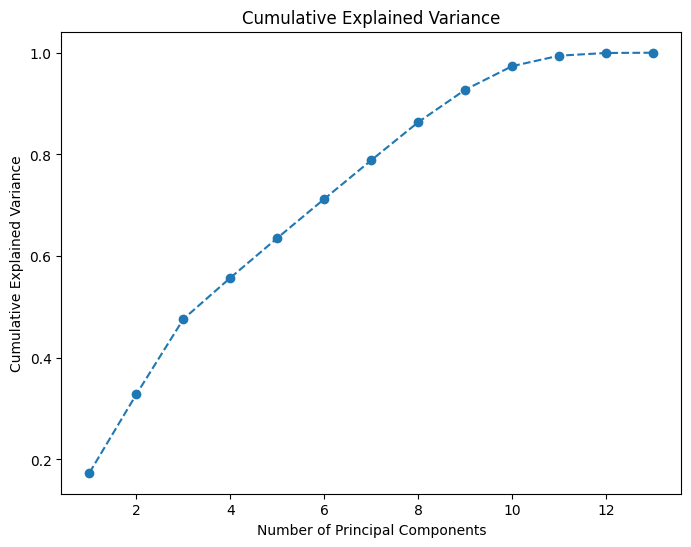

In [11]:
# Cumulative explained variance plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

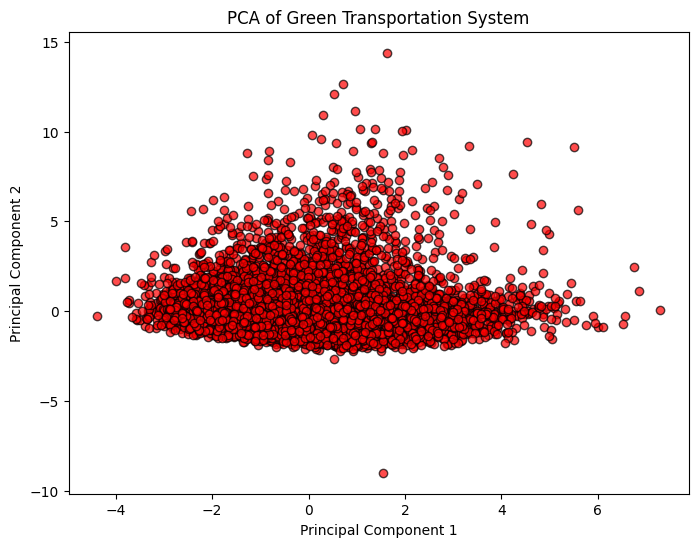

In [12]:
# Project the data onto the first two principal components
data_pca = pca.transform(data_scaled)
# Create a DataFrame with the first two principal components
pca_df = pd.DataFrame(data_pca[:, :2], columns=['PC1', 'PC2'])
# Visualize the data in 2D space using the first two principal components
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c='red', edgecolors='k', alpha=0.7)
plt.title('PCA of Green Transportation System')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()